# Assignment 4 — Tabular RL Methods: Windy Gridworld
### MMAI-845 · Reinforcement Learning · Spring 2026

This notebook implements **SARSA** and **Q-Learning** on the Windy Gridworld, tunes hyperparameters, and compares the two algorithms.

---

## 1. Setup

We import the provided assignment files directly — `windy_gridworld.py` (environment) and `tabular.py` (algorithms with our completed update rules).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import windy_gridworld
import tabular

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

env = windy_gridworld.StochWindyGridWorldEnv()
print(f"Grid:    {env.grid_width} × {env.grid_height}")
print(f"Start:   {env.start_cell}")
print(f"Goal:    {env.goal_cell}")
print(f"Wind:    {env.wind}")
print(f"Actions: {env.action_space.n}")

Grid:    10 × 7
Start:   [0 3]
Goal:    [7 4]
Wind:    [0 0 0 1 1 1 2 2 1 0]
Actions: 4


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 2. Understanding the Environment

The agent starts at **S** and must reach **G**. Every step costs **−1** reward. Columns 3–8 have upward wind that pushes the agent up on top of their chosen action. The optimal path takes **14 steps** (reward = −14).

### Grid Layout

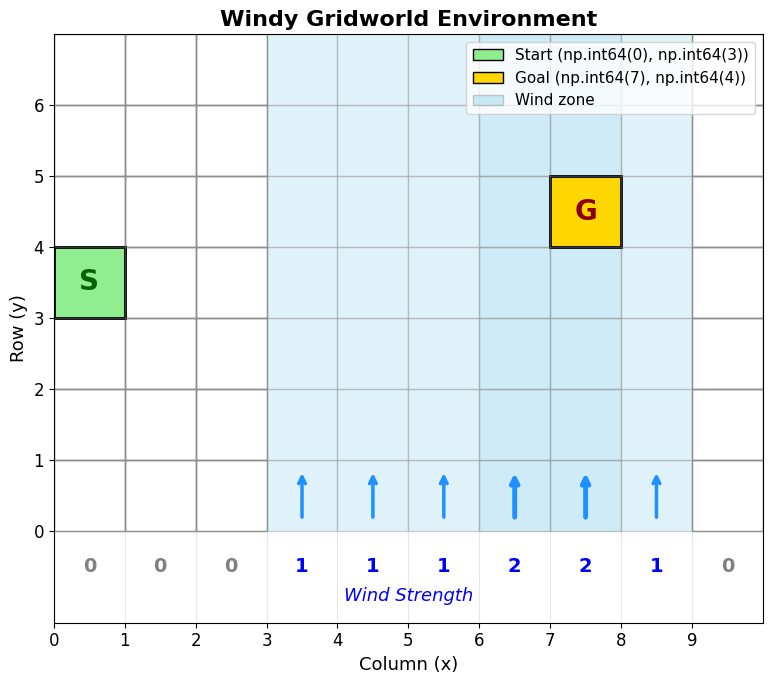

In [2]:
fig, ax = plt.subplots(figsize=(12, 7))

for x in range(env.grid_width):
    for y in range(env.grid_height):
        w = env.wind[x]
        if w > 0:
            ax.add_patch(plt.Rectangle((x, y), 1, 1, facecolor='skyblue',
                                        alpha=0.1 + 0.15 * w, edgecolor='gray'))
        else:
            ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='gray'))

# Start and Goal
ax.add_patch(plt.Rectangle((env.start_cell[0], env.start_cell[1]), 1, 1,
                             facecolor='#90EE90', edgecolor='black', linewidth=2))
ax.text(env.start_cell[0]+0.5, env.start_cell[1]+0.5, 'S', ha='center', va='center',
        fontsize=20, fontweight='bold', color='darkgreen')
ax.add_patch(plt.Rectangle((env.goal_cell[0], env.goal_cell[1]), 1, 1,
                             facecolor='#FFD700', edgecolor='black', linewidth=2))
ax.text(env.goal_cell[0]+0.5, env.goal_cell[1]+0.5, 'G', ha='center', va='center',
        fontsize=20, fontweight='bold', color='darkred')

for x in range(env.grid_width):
    w = env.wind[x]
    ax.text(x+0.5, -0.5, str(w), ha='center', va='center', fontsize=14, fontweight='bold',
            color='blue' if w > 0 else 'gray')
    if w > 0:
        ax.annotate('', xy=(x+0.5, 0.85), xytext=(x+0.5, 0.15),
                    arrowprops=dict(arrowstyle='->', color='dodgerblue', lw=1.5+w))

ax.text(5, -1.0, 'Wind Strength', ha='center', fontsize=13, fontstyle='italic', color='blue')
ax.set_xlim(0, env.grid_width)
ax.set_ylim(-1.3, env.grid_height)
ax.set_aspect('equal')
ax.set_xticks(range(env.grid_width))
ax.set_yticks(range(env.grid_height))
ax.set_xlabel('Column (x)', fontsize=13)
ax.set_ylabel('Row (y)', fontsize=13)
ax.set_title('Windy Gridworld Environment', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(handles=[
    mpatches.Patch(facecolor='#90EE90', edgecolor='black', label=f'Start {tuple(env.start_cell)}'),
    mpatches.Patch(facecolor='#FFD700', edgecolor='black', label=f'Goal {tuple(env.goal_cell)}'),
    mpatches.Patch(facecolor='skyblue', alpha=0.4, edgecolor='gray', label='Wind zone'),
], loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

### How the Wind Works

Let's step through a few actions manually to see wind in action:

In [3]:
env_demo = windy_gridworld.StochWindyGridWorldEnv()
state = env_demo.reset()
print(f"Start state: {state}")
print("─" * 60)

demo_actions = [2, 2, 2, 2, 0, 2, 2, 2]  # RIGHT×4, UP, RIGHT×3
action_names = ['RIGHT', 'RIGHT', 'RIGHT', 'RIGHT', 'UP', 'RIGHT', 'RIGHT', 'RIGHT']

for i, (act, name) in enumerate(zip(demo_actions, action_names)):
    old = state.copy()
    w = env_demo.wind[old[0]]
    state, reward, done, _ = env_demo.step(act)
    print(f"Step {i+1}: At {old} → {name:5s} (wind={w}) → landed at {state}  [reward={reward}]")
    if done:
        print(f"\nReached goal in {i+1} steps! Total reward = {-(i+1)}")
        break

if not done:
    print(f"\nDid not reach goal in {len(demo_actions)} steps. Position: {state}")

Start state: [0 3]
────────────────────────────────────────────────────────────
Step 1: At [0 3] → RIGHT (wind=0) → landed at [1 3]  [reward=-1]
Step 2: At [1 3] → RIGHT (wind=0) → landed at [2 3]  [reward=-1]
Step 3: At [2 3] → RIGHT (wind=0) → landed at [3 3]  [reward=-1]
Step 4: At [3 3] → RIGHT (wind=1) → landed at [4 4]  [reward=-1]
Step 5: At [4 4] → UP    (wind=1) → landed at [4 6]  [reward=-1]
Step 6: At [4 6] → RIGHT (wind=1) → landed at [5 6]  [reward=-1]
Step 7: At [5 6] → RIGHT (wind=1) → landed at [6 6]  [reward=-1]
Step 8: At [6 6] → RIGHT (wind=2) → landed at [7 6]  [reward=-1]

Did not reach goal in 8 steps. Position: [7 6]


## 3. SARSA vs Q-Learning — Key Differences

Both algorithms share the same core structure, updating Q-values using the **TD error**:

$$Q(S,A) \leftarrow Q(S,A) + \alpha \cdot \underbrace{\left[ R + \gamma \cdot (\text{future estimate}) - Q(S,A) \right]}_{\text{TD Error}}$$

The single difference is what "future estimate" means:

| | SARSA (on-policy) | Q-Learning (off-policy) |
|---|---|---|
| **Future estimate** | $Q(S', A')$ — the ε-greedy action we'll *actually* take | $\max_a Q(S', a)$ — the *best possible* action |
| **Behavior** | Conservative (accounts for exploration mistakes) | Optimistic (assumes optimal future behavior) |
| **Action selection** | A chosen *before* inner loop; A' carried forward | A chosen *inside* inner loop each step |

Our three code changes in `tabular.py`:
```python
# Task 1.1 — SARSA update
q_table[state[0], state[1], action] = q + step_size * (rew + gamma * q_prime - q)

# Task 2.1 — Q-learning best next action
q_prime = np.max(q_all_actions)

# Task 2.2 — Q-learning update
q_table[state[0], state[1], action] = q + step_size * (rew + gamma * q_prime - q)
```

## 4. Run Both Algorithms & Compare

In [4]:
# ── Helpers ──────────────────────────────────────────────────────

def evaluate_greedy(q_table, env, max_steps=50):
    """Run the greedy policy and return total reward + path taken."""
    state = env.reset()
    path = [state.copy()]
    total_reward = 0
    for _ in range(max_steps):
        action = np.argmax(q_table[state[0], state[1], :])
        state, reward, done, _ = env.step(action)
        path.append(state.copy())
        total_reward += reward
        if done:
            break
    return total_reward, path

def plot_path(path, env, title, ax):
    """Plot agent path on a grid axis."""
    for x in range(env.grid_width):
        for y in range(env.grid_height):
            w = env.wind[x]
            if w > 0:
                ax.add_patch(plt.Rectangle((x, y), 1, 1, facecolor='skyblue',
                                            alpha=0.1+0.15*w, edgecolor='gray'))
            else:
                ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='gray'))

    ax.add_patch(plt.Rectangle((env.start_cell[0], env.start_cell[1]), 1, 1,
                                 facecolor='#90EE90', alpha=0.5, edgecolor='black', lw=2))
    ax.text(env.start_cell[0]+0.5, env.start_cell[1]+0.5, 'S', ha='center', va='center',
            fontsize=14, fontweight='bold', color='darkgreen')
    ax.add_patch(plt.Rectangle((env.goal_cell[0], env.goal_cell[1]), 1, 1,
                                 facecolor='#FFD700', alpha=0.5, edgecolor='black', lw=2))
    ax.text(env.goal_cell[0]+0.5, env.goal_cell[1]+0.5, 'G', ha='center', va='center',
            fontsize=14, fontweight='bold', color='darkred')

    xs = [p[0]+0.5 for p in path]
    ys = [p[1]+0.5 for p in path]
    ax.plot(xs, ys, 'ro-', markersize=5, linewidth=2, alpha=0.7, label=f'{len(path)-1} steps')
    for i, (x, y) in enumerate(zip(xs, ys)):
        ax.annotate(str(i), (x, y), textcoords="offset points", xytext=(4, 4), fontsize=7, color='red')

    for x in range(env.grid_width):
        ax.text(x+0.5, -0.4, str(env.wind[x]), ha='center', fontsize=11,
                fontweight='bold', color='blue' if env.wind[x] > 0 else 'gray')

    ax.set_xlim(0, env.grid_width)
    ax.set_ylim(-0.7, env.grid_height)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelbottom=False, labelleft=False)

def plot_policy(q_table, env, title, ax):
    """Plot greedy policy arrows on a grid axis."""
    arrow_map = {0: (0, 0.3), 1: (0, -0.3), 2: (0.3, 0), 3: (-0.3, 0)}
    for x in range(env.grid_width):
        for y in range(env.grid_height):
            w = env.wind[x]
            if w > 0:
                ax.add_patch(plt.Rectangle((x, y), 1, 1, facecolor='skyblue',
                                            alpha=0.1+0.15*w, edgecolor='gray'))
            else:
                ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='gray'))
            best = np.argmax(q_table[x, y, :])
            dx, dy = arrow_map[best]
            ax.arrow(x+0.5, y+0.5, dx, dy, head_width=0.07, head_length=0.07,
                     fc='black', ec='black', linewidth=1)

    ax.add_patch(plt.Rectangle((env.start_cell[0], env.start_cell[1]), 1, 1,
                                 facecolor='#90EE90', alpha=0.7, edgecolor='black', lw=2))
    ax.text(env.start_cell[0]+0.5, env.start_cell[1]+0.5, 'S', ha='center', va='center',
            fontsize=14, fontweight='bold', color='darkgreen')
    ax.add_patch(plt.Rectangle((env.goal_cell[0], env.goal_cell[1]), 1, 1,
                                 facecolor='#FFD700', alpha=0.7, edgecolor='black', lw=2))
    ax.text(env.goal_cell[0]+0.5, env.goal_cell[1]+0.5, 'G', ha='center', va='center',
            fontsize=14, fontweight='bold', color='darkred')

    for x in range(env.grid_width):
        ax.text(x+0.5, -0.4, str(env.wind[x]), ha='center', fontsize=11,
                fontweight='bold', color='blue' if env.wind[x] > 0 else 'gray')
    ax.set_xlim(0, env.grid_width)
    ax.set_ylim(-0.7, env.grid_height)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelbottom=False, labelleft=False)

print("Helpers defined.")

Helpers defined.


### Train Both Algorithms

**Hyperparameters (Tasks 1.2 & 2.3):** `α=0.5`, `ε=0.05`, `γ=1.0`, `500 episodes`

In [5]:
# ── Train ────────────────────────────────────────────────────────
np.random.seed(42)
env = windy_gridworld.StochWindyGridWorldEnv()
sarsa_rews, sarsa_table = tabular.sarsa(env, step_size=0.5, epsilon=0.05, gamma=1.0, num_eps=500)
sarsa_total, sarsa_path = evaluate_greedy(sarsa_table, env)

np.random.seed(42)
env = windy_gridworld.StochWindyGridWorldEnv()
ql_rews, ql_table = tabular.q_learning(env, step_size=0.5, epsilon=0.05, gamma=1.0, num_eps=500)
ql_total, ql_path = evaluate_greedy(ql_table, env)

print(f"SARSA      → greedy reward: {sarsa_total}  ({len(sarsa_path)-1} steps)")
print(f"Q-Learning → greedy reward: {ql_total}  ({len(ql_path)-1} steps)")
print(f"Optimal:     -14")
print(f"Target:      ≥ -16")
print(f"SARSA:       {'PASS' if sarsa_total >= -16 else 'FAIL'}")
print(f"Q-Learning:  {'PASS' if ql_total >= -16 else 'FAIL'}")

SARSA      → greedy reward: -14  (14 steps)
Q-Learning → greedy reward: -14  (14 steps)
Optimal:     -14
Target:      ≥ -16
SARSA:       PASS
Q-Learning:  PASS


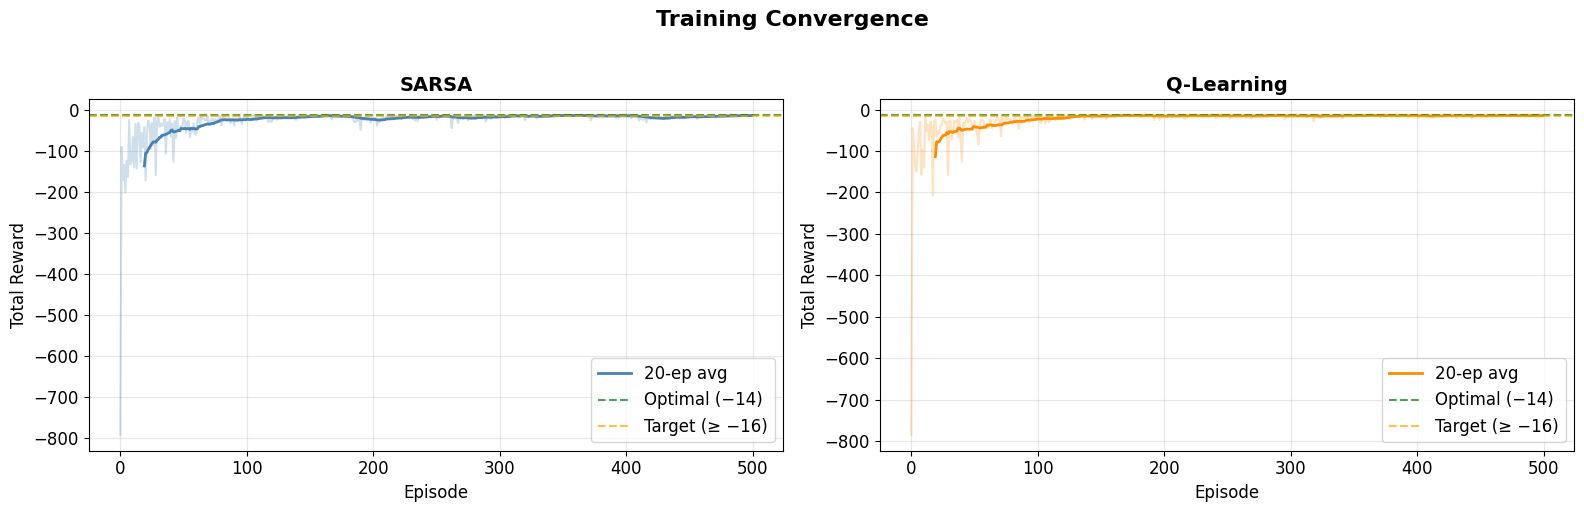

In [6]:
# ── Reward Convergence Comparison ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
window = 20

for ax, rews, name, color in [
    (axes[0], sarsa_rews, 'SARSA', 'steelblue'),
    (axes[1], ql_rews, 'Q-Learning', 'darkorange')
]:
    ax.plot(rews, alpha=0.25, color=color)
    rolling = np.convolve(rews, np.ones(window)/window, mode='valid')
    ax.plot(range(window-1, len(rews)), rolling, color=color, linewidth=2, label=f'{window}-ep avg')
    ax.axhline(y=-14, color='green', linestyle='--', alpha=0.7, label='Optimal (−14)')
    ax.axhline(y=-16, color='orange', linestyle='--', alpha=0.7, label='Target (≥ −16)')
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Convergence', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

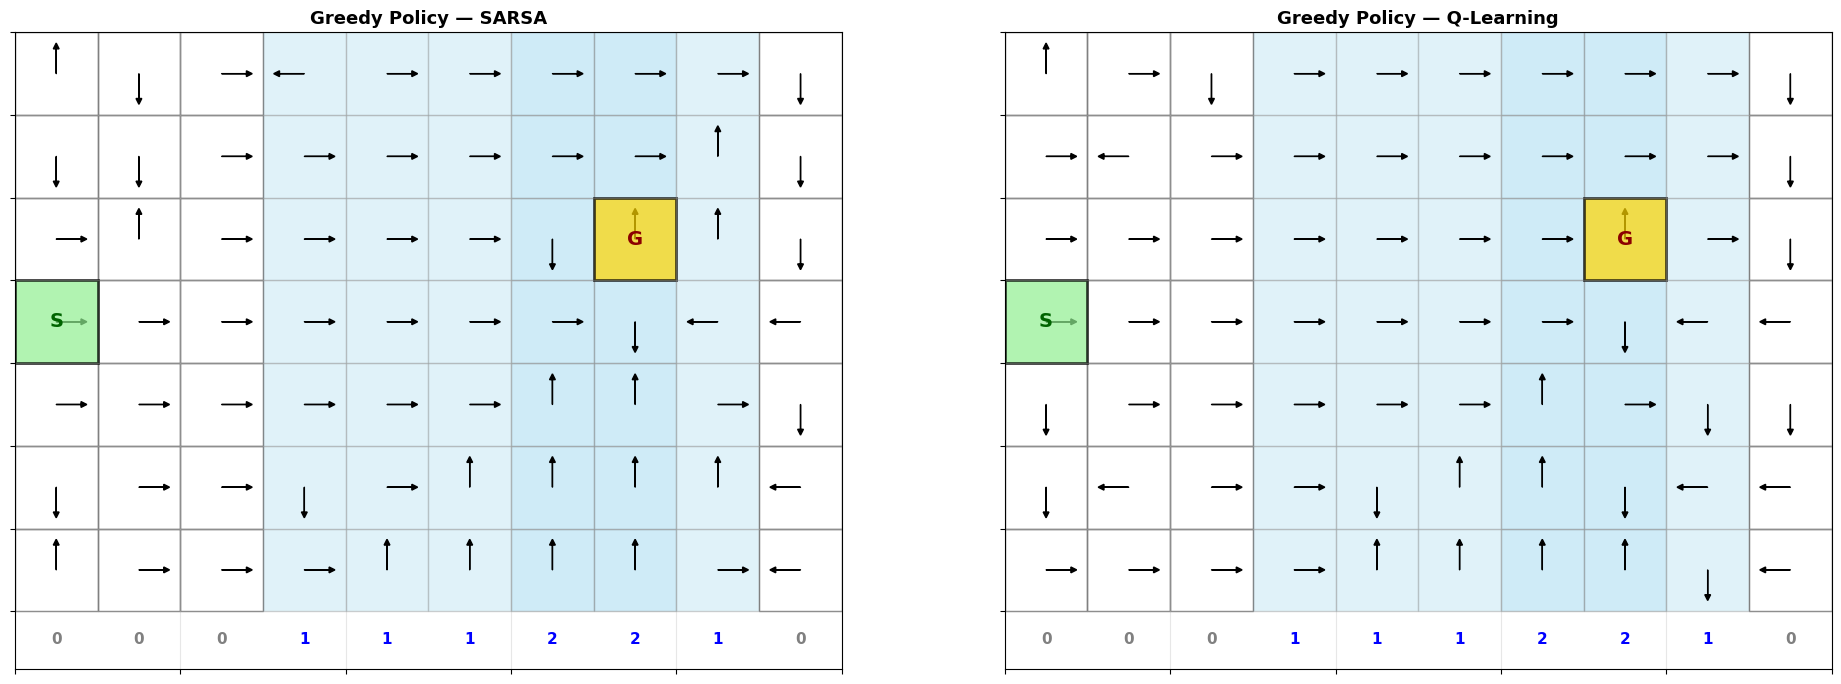

In [7]:
# ── Greedy Policies Side-by-Side ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
plot_policy(sarsa_table, env, 'Greedy Policy — SARSA', axes[0])
plot_policy(ql_table, env, 'Greedy Policy — Q-Learning', axes[1])
plt.tight_layout()
plt.show()

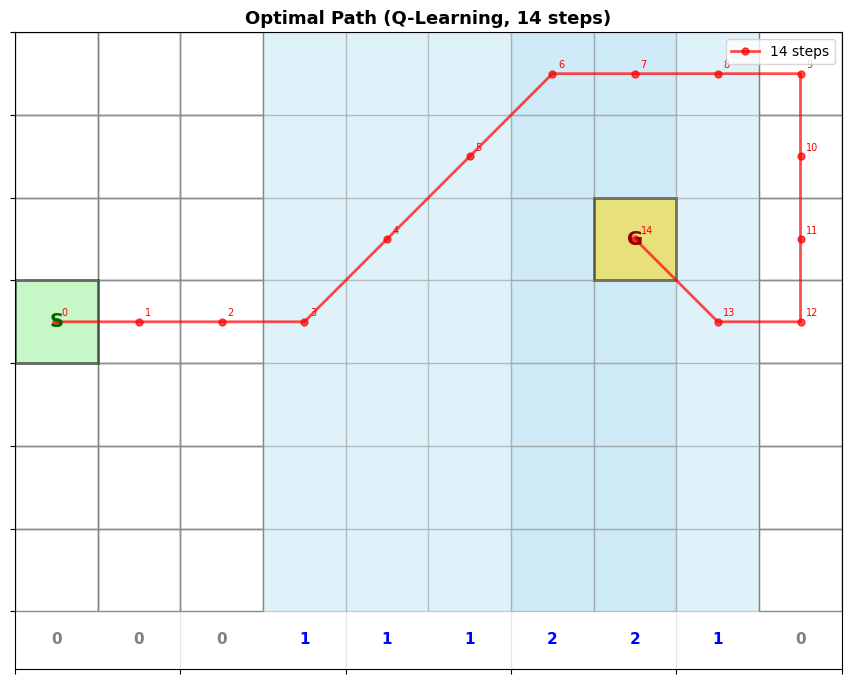

In [8]:
# ── Learned Path (Q-Learning — same as SARSA, both reach -14) ────
fig, ax = plt.subplots(figsize=(12, 7))
plot_path(ql_path, env, 'Optimal Path (Q-Learning, 14 steps)', ax)
plt.tight_layout()
plt.show()

## 5. Hyperparameter Experiments

The assignment asks us to *understand the effect* of each parameter. We sweep one parameter at a time while holding the others fixed.

### Experiment 1: Learning Rate (α)

α controls how aggressively Q-values update per step. Too small → slow convergence. Too large → noisy oscillation.

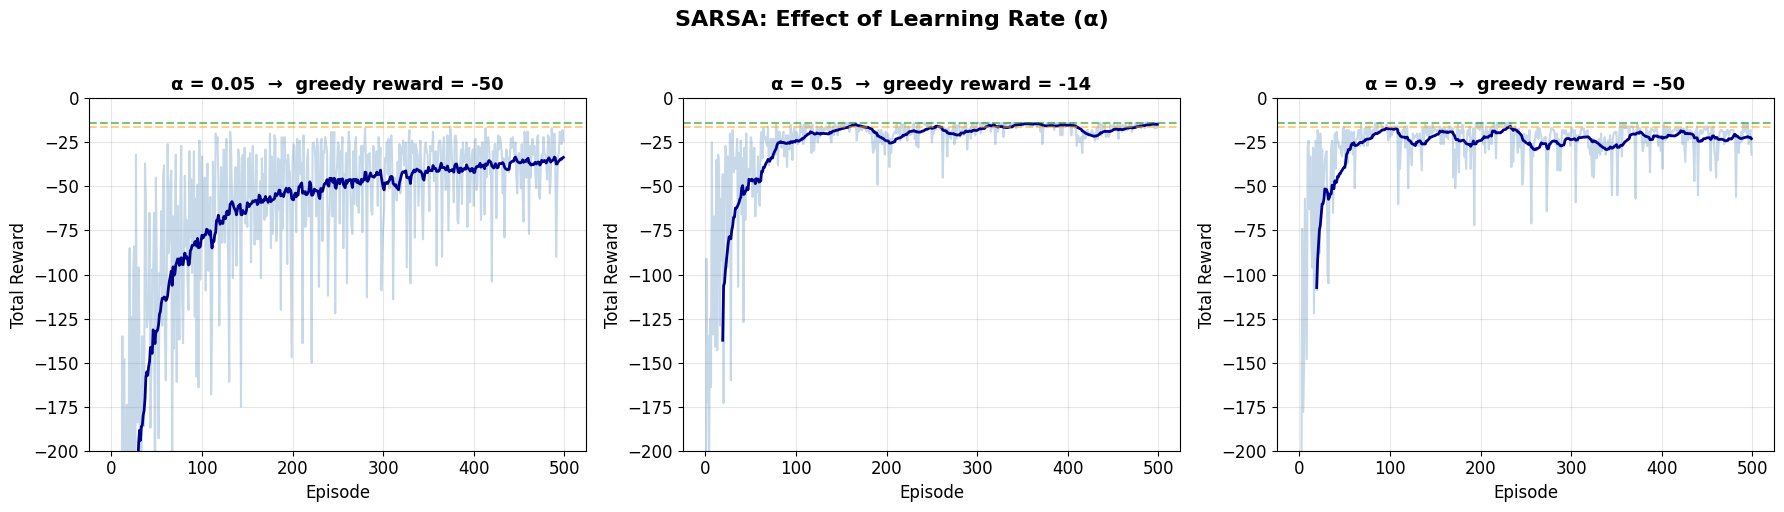

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
window = 20

for ax, alpha in zip(axes, [0.05, 0.5, 0.9]):
    np.random.seed(42)
    env = windy_gridworld.StochWindyGridWorldEnv()
    rews, table = tabular.sarsa(env, step_size=alpha, epsilon=0.05, gamma=1.0, num_eps=500)
    total, _ = evaluate_greedy(table, env)
    
    ax.plot(rews, alpha=0.3, color='steelblue')
    rolling = np.convolve(rews, np.ones(window)/window, mode='valid')
    ax.plot(range(window-1, len(rews)), rolling, color='darkblue', linewidth=2)
    ax.axhline(y=-14, color='green', linestyle='--', alpha=0.5)
    ax.axhline(y=-16, color='orange', linestyle='--', alpha=0.5)
    ax.set_title(f'α = {alpha}  →  greedy reward = {total}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.set_ylim(-200, 0)
    ax.grid(True, alpha=0.3)

plt.suptitle('SARSA: Effect of Learning Rate (α)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Experiment 2: Exploration Rate (ε)

ε controls random exploration. Too low → stuck on suboptimal policy. Too high → never commits to good actions. Assignment says keep under 10%.

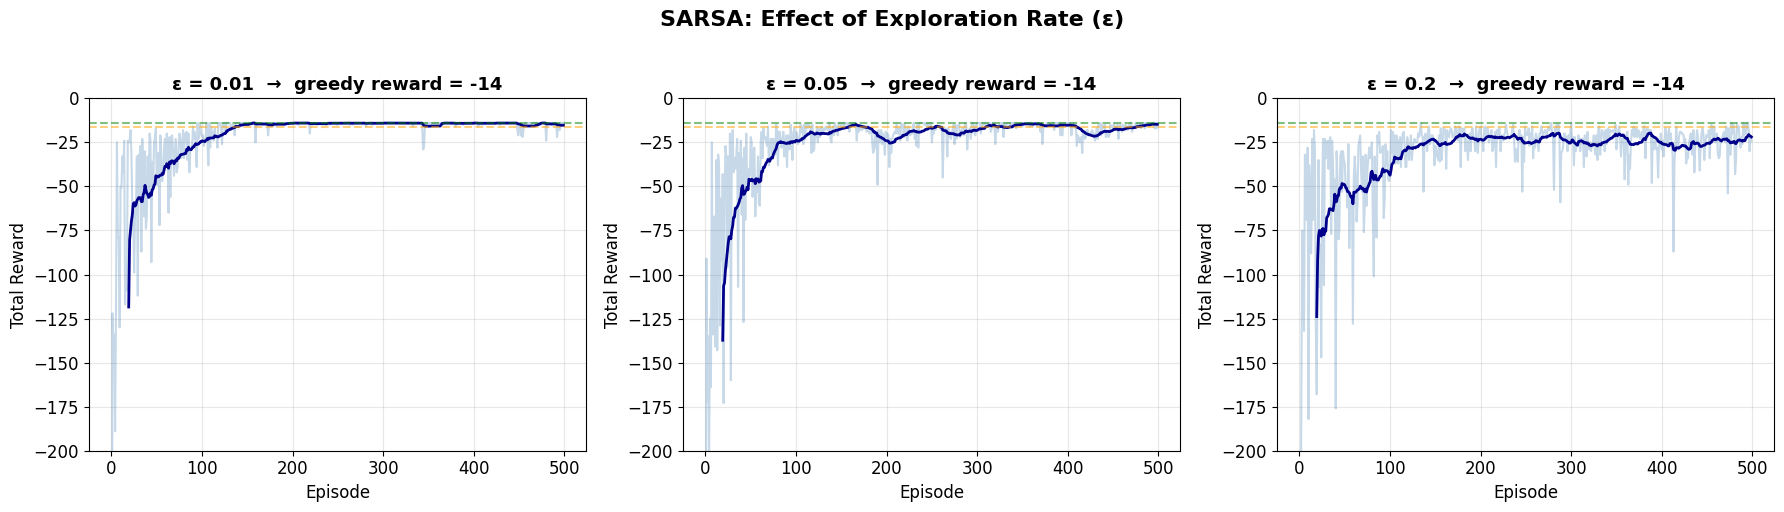

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, eps in zip(axes, [0.01, 0.05, 0.20]):
    np.random.seed(42)
    env = windy_gridworld.StochWindyGridWorldEnv()
    rews, table = tabular.sarsa(env, step_size=0.5, epsilon=eps, gamma=1.0, num_eps=500)
    total, _ = evaluate_greedy(table, env)
    
    ax.plot(rews, alpha=0.3, color='steelblue')
    rolling = np.convolve(rews, np.ones(window)/window, mode='valid')
    ax.plot(range(window-1, len(rews)), rolling, color='darkblue', linewidth=2)
    ax.axhline(y=-14, color='green', linestyle='--', alpha=0.5)
    ax.axhline(y=-16, color='orange', linestyle='--', alpha=0.5)
    ax.set_title(f'ε = {eps}  →  greedy reward = {total}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.set_ylim(-200, 0)
    ax.grid(True, alpha=0.3)

plt.suptitle('SARSA: Effect of Exploration Rate (ε)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Experiment 3: Number of Episodes

When do rewards flatten? We train for 1000 episodes and check convergence at various cutoffs.

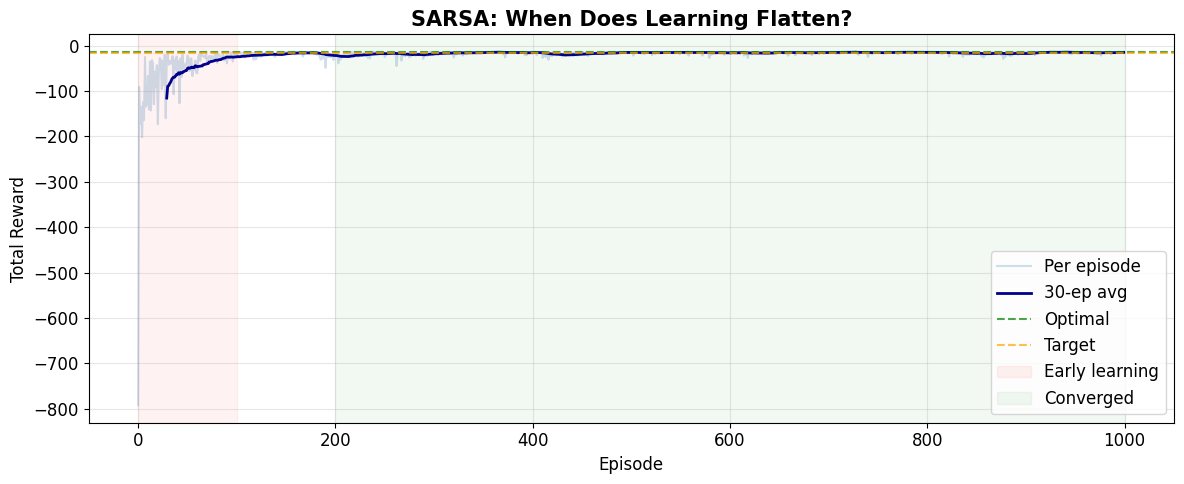

   100 episodes → greedy reward =  -50  ✗
   200 episodes → greedy reward =  -50  ✗


   300 episodes → greedy reward =  -14  ✓


   500 episodes → greedy reward =  -14  ✓


In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

np.random.seed(42)
env = windy_gridworld.StochWindyGridWorldEnv()
rews, _ = tabular.sarsa(env, step_size=0.5, epsilon=0.05, gamma=1.0, num_eps=1000)

ax.plot(rews, alpha=0.25, color='steelblue', label='Per episode')
window = 30
rolling = np.convolve(rews, np.ones(window)/window, mode='valid')
ax.plot(range(window-1, len(rews)), rolling, color='darkblue', linewidth=2, label=f'{window}-ep avg')
ax.axhline(y=-14, color='green', linestyle='--', alpha=0.7, label='Optimal')
ax.axhline(y=-16, color='orange', linestyle='--', alpha=0.7, label='Target')
ax.axvspan(0, 100, alpha=0.05, color='red', label='Early learning')
ax.axvspan(200, 1000, alpha=0.05, color='green', label='Converged')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('SARSA: When Does Learning Flatten?', fontsize=15, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Convergence check at different cutoffs
for cutoff in [100, 200, 300, 500]:
    np.random.seed(42)
    env = windy_gridworld.StochWindyGridWorldEnv()
    _, t = tabular.sarsa(env, step_size=0.5, epsilon=0.05, gamma=1.0, num_eps=cutoff)
    r, _ = evaluate_greedy(t, env)
    print(f"  {cutoff:4d} episodes → greedy reward = {r:4d}  {'✓' if r >= -16 else '✗'}")

## 6. Summary

| Parameter | Value | Rationale |
|---|---|---|
| α (step_size) | 0.5 | Fast convergence without instability |
| ε (epsilon) | 0.05 | 5% exploration — under the 10% cap, enough to discover good paths |
| γ (gamma) | 1.0 | Required (undiscounted episodic task) |
| num_eps | 500 | Rewards flatten by ~200; 500 gives safe margin |

Both SARSA and Q-Learning achieve the **optimal reward of −14** with these parameters, well above the −16 threshold.